# Exercise 4.2: Learning network structures
In this exercise we will see some examples of learning the structure of the network from data.

We will look at the following algorithms

- PC
- Hill-Climb Search
- Exhaustive Search


Once you have familiarised yourself with the code you should explore chinging the Scoring metrcis and the structure of models to learnig your own models.

## As in exercise 4.1 we need to generate some data

To do this we first create a network and then sample data from it

We can draw the networks using the networkx package

Aric A. Hagberg, Daniel A. Schult and Pieter J. Swart, “Exploring network structure, dynamics, and function using NetworkX”, in Proceedings of the 7th Python in Science Conference (SciPy2008), Gäel Varoquaux, Travis Vaught, and Jarrod Millman (Eds), (Pasadena, CA USA), pp. 11–15, Aug 2008

https://networkx.org/

In [14]:
#This code is modified from the examples at pgmpy.org Copyright (c) 2013-2021 pgmpy
import numpy as np
from itertools import combinations

import networkx as nx
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

from pgmpy.models import BayesianModel

from pgmpy.estimators import PC, HillClimbSearch, ExhaustiveSearch
from pgmpy.estimators import K2Score
from pgmpy.utils import get_example_model
from pgmpy.sampling import BayesianModelSampling

C:\Users\wesle\AppData\Roaming\Python\Python39\site-packages\pgmpy\models\BayesianModel.py:8: FutureWarning: BayesianModel has been renamed to BayesianNetwork. Please use BayesianNetwork class, BayesianModel will be removed in future.
  warnings.warn(


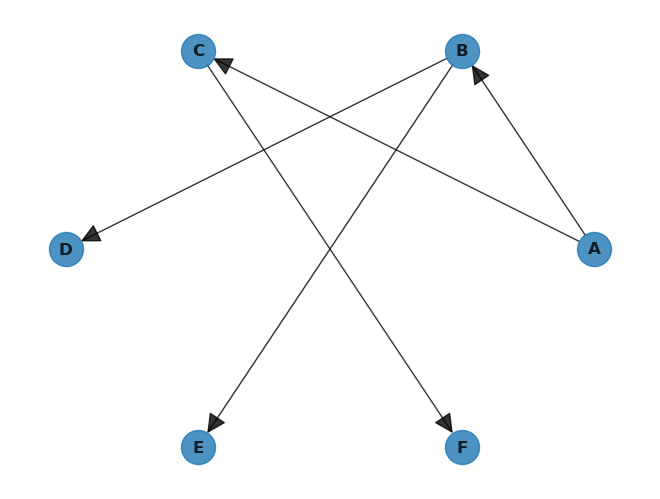

In [15]:
model = BayesianModel([('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'F')])
nx.draw_circular(model, with_labels=True, arrowsize=30, node_size=600, alpha=0.8, font_weight='bold')
plt.show()

In [16]:
from pgmpy.factors.discrete import TabularCPD

# add CPD to each edge
cpd_a = TabularCPD('A', 2, [[0.4], [0.6]])
cpd_b = TabularCPD('B', 3, [[0.6,0.2],[0.3,0.5],[0.1,0.3]], evidence=['A'], evidence_card=[2])
cpd_c = TabularCPD('C', 2, [[0.3,0.4],[0.7,0.6]], evidence=['A'], evidence_card=[2])
cpd_d = TabularCPD('D', 3, [[0.5,0.3,0.1],[0.4,0.4,0.8],[0.1,0.3,0.1]], evidence=['B'], evidence_card=[3])
cpd_e = TabularCPD('E', 2, [[0.3,0.5,0.2],[0.7,0.5,0.8]], evidence=['B'], evidence_card=[3])
cpd_f = TabularCPD('F', 3, [[0.3,0.6],[0.5,0.2],[0.2,0.2]], evidence=['C'], evidence_card=[2])
model.add_cpds(cpd_a, cpd_b, cpd_c, cpd_d, cpd_e, cpd_f)

We can now use the model to generate our samples

In [17]:
from pgmpy.sampling import BayesianModelSampling

# sample data from BN
inference = BayesianModelSampling(model)
samples = inference.forward_sample(size=10000)
print(samples)

  0%|          | 0/6 [00:00<?, ?it/s]

C:\Users\wesle\AppData\Roaming\Python\Python39\site-packages\pgmpy\utils\mathext.py:82: UserWarning: Probability values don't exactly sum to 1. Differ by: 1.1102230246251565e-16. Adjusting values.
  warn(


      A  B  C  D  E  F
0     0  1  1  2  1  0
1     0  0  1  0  0  1
2     1  1  0  1  0  0
3     1  2  1  0  1  1
4     1  1  1  1  0  0
...  .. .. .. .. .. ..
9995  1  0  1  1  0  1
9996  1  2  1  1  1  0
9997  0  0  0  0  1  1
9998  0  1  0  1  0  1
9999  0  0  0  0  1  1

[10000 rows x 6 columns]


Now that we have some samples we can try to learn the structure

## Learning the model structure using PC

The PC algorithm starts with a complete, undirected graph and deletes recursively edges based on conditional independence decisions. It was named after its authors (Peter and Clark).

Peter Spirtes, Clark Glymour, and Richard Scheines. Causation, Prediction, and Search. Adaptive Computation and Machine Learning. MIT Press, Cambridge, MA, second edition, 2000. With additional material by David Heckerman, Christopher Meek, Gregory F. Cooper and ThomasRichardson, A Bradford Book.

For PC the following conditional independence test can be used:

- Chi-Square test (https://en.wikipedia.org/wiki/Chi-squared_test)
- Pearsonr (https://en.wikipedia.org/wiki/Partial_correlation#Using_linear_regression)
- G-squared (https://en.wikipedia.org/wiki/G-test)
- Log-likelihood (https://en.wikipedia.org/wiki/G-test)
- Freeman-Tuckey (Read, Campbell B. "Freeman—Tukey chi-squared goodness-of-fit statistics." Statistics & probability letters 18.4 (1993): 271-278.)
- Modified Log-likelihood
Neymann (https://en.wikipedia.org/wiki/Neyman%E2%80%93Pearson_lemma)
- Cressie Read (Cressie, Noel, and Timothy RC Read. "Multinomial goodness‐of‐fit tests." Journal of the Royal Statistical Society: Series B (Methodological) 46.3 (1984): 440-464)
- Power Divergence (Cressie, Noel, and Timothy RC Read. "Multinomial goodness‐of‐fit tests." Journal of the Royal Statistical Society: Series B (Methodological) 46.3 (1984): 440-464.)

We need a function to evaluate how well the structures fit the data

In [18]:
# Function to evaluate the learned model structures.
def get_f1_score(estimated_model, true_model):
    nodes = estimated_model.nodes()
    est_adj = nx.to_numpy_matrix(estimated_model.to_undirected(), nodelist=nodes, weight=None)
    true_adj = nx.to_numpy_matrix(true_model.to_undirected(), nodelist=nodes, weight=None)
    
    f1 = f1_score(np.ravel(true_adj), np.ravel(est_adj))
    print("F1-score for the model skeleton: ", f1)

In [19]:
est = PC(data=samples)
estimated_model = est.estimate(variant='stable', max_cond_vars=10)
get_f1_score(estimated_model, model)

  0%|          | 0/10 [00:00<?, ?it/s]

F1-score for the model skeleton:  1.0


We can then display the estimated model 

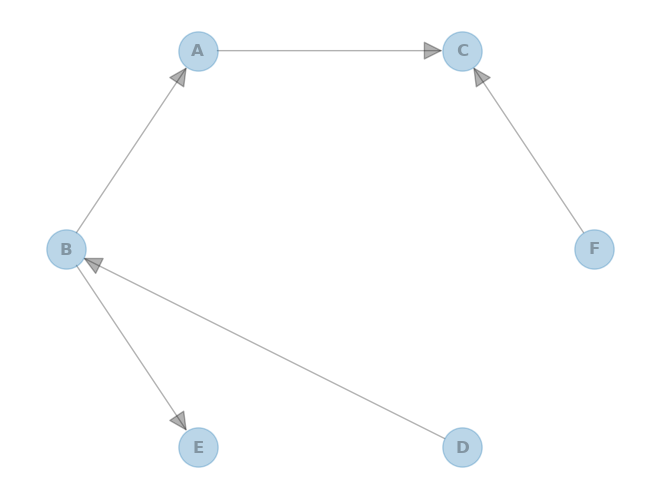

In [20]:
nx.draw_circular(estimated_model, with_labels=True, arrowsize=30, node_size=800, alpha=0.3, font_weight='bold')
plt.show()

Note that although the network is displayed differently it has the same structure although some of the edges are in different directions.

## Learn the model structure using Hill-Climb 

- For Hill-Climb and Exhausitive Search the following scoring methods can be used:

    - K2 Score
    - BDeu Score
    - Bic Score
    
Performs local hill climb search to estimate the DAG structure that has optimal score, according to the scoring method supplied. Proceeds by step-by-step network modifications until a local maximum is reached. Only estimates network structure, no parametrization.

In [21]:
scoring_method = K2Score(data=samples)
est = HillClimbSearch(data=samples)
estimated_model = est.estimate(scoring_method=scoring_method, max_indegree=4, max_iter=int(1e4))

  0%|          | 0/10000 [00:00<?, ?it/s]

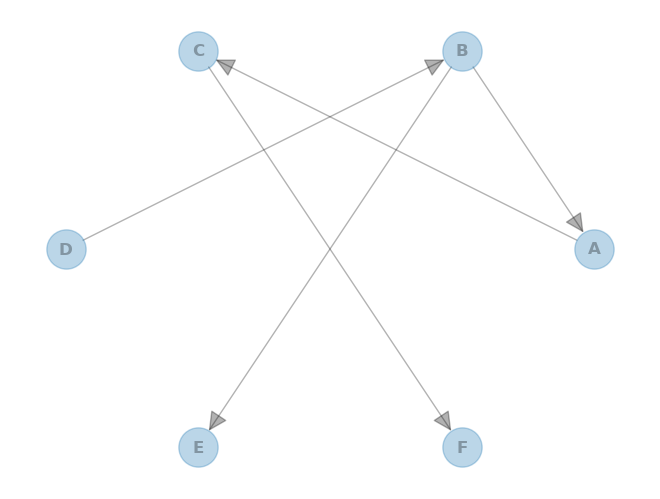

In [22]:
nx.draw_circular(estimated_model, with_labels=True, arrowsize=30, node_size=800, alpha=0.3, font_weight='bold')
plt.show()

## Learning the model structure using Exhaustive Search 

- For Hill-Climb and Exhausitive Search the following scoring methods can be used:

    - K2 Score
    - BDeu Score
    - Bic Score
    
Exhaustive search computes all possible directed acyclic graphs with a given set of nodes, sparse ones first. 2**(n*(n-1)) graphs need to be searched, given n nodes, so this is likely not feasible for n>6. We can therefore only use it for very simple domains.

In [26]:
import pandas as pd
import numpy as np
from pgmpy.estimators import ExhaustiveSearch
# create a random data sample with 3 variables, where B and C are identical:
data = pd.DataFrame(np.random.randint(0, 5, size=(5000, 2)), columns=list('AB'))
data['C'] = data['B']/2 # to make these nodes very similar

scoring_method = K2Score(data)
est = ExhaustiveSearch(data,scoring_method=scoring_method)
best_model = est.estimate()

In [27]:
data.head()

,A,B,C
0,3,0,0.0
1,2,3,1.5
2,0,1,0.5
3,3,1,0.5
4,0,1,0.5


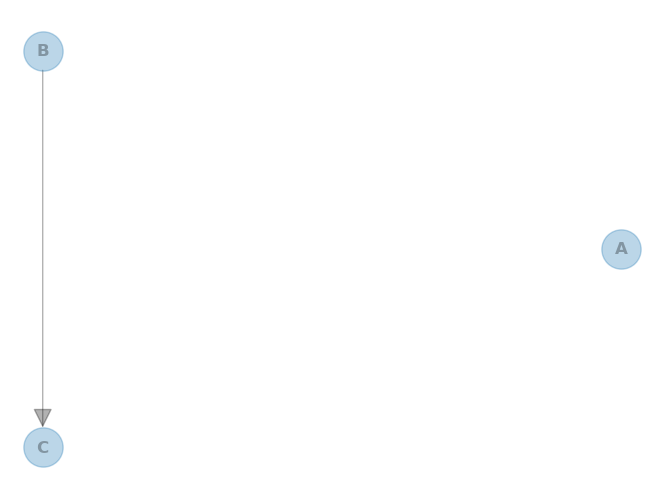

In [28]:
nx.draw_circular(best_model, with_labels=True, arrowsize=30, node_size=800, alpha=0.3, font_weight='bold')
plt.show()

# Medical diagnosis example

As used in the previous exercise we can apply the same approach to learn the structure of the alarm model.

First we generate our samples

In [29]:
model = get_example_model('alarm')
samples = BayesianModelSampling(model).forward_sample(size=int(1e3))
samples.head()

  0%|          | 0/37 [00:00<?, ?it/s]

C:\Users\wesle\AppData\Roaming\Python\Python39\site-packages\pgmpy\utils\mathext.py:82: UserWarning: Probability values don't exactly sum to 1. Differ by: 1.0000000005838672e-07. Adjusting values.
  warn(
C:\Users\wesle\AppData\Roaming\Python\Python39\site-packages\pgmpy\utils\mathext.py:82: UserWarning: Probability values don't exactly sum to 1. Differ by: 1.1102230246251565e-16. Adjusting values.
  warn(


,HISTORY,CVP,PCWP,HYPOVOLEMIA,LVEDVOLUME,LVFAILURE,STROKEVOLUME,ERRLOWOUTPUT,HRBP,HREKG,...,MINVOLSET,VENTMACH,VENTTUBE,VENTLUNG,VENTALV,ARTCO2,CATECHOL,HR,CO,BP
0,FALSE,NORMAL,NORMAL,FALSE,NORMAL,FALSE,NORMAL,FALSE,LOW,LOW,...,NORMAL,NORMAL,LOW,ZERO,ZERO,HIGH,NORMAL,NORMAL,NORMAL,LOW
1,FALSE,NORMAL,LOW,FALSE,NORMAL,FALSE,LOW,FALSE,HIGH,HIGH,...,NORMAL,NORMAL,LOW,ZERO,ZERO,HIGH,HIGH,HIGH,LOW,LOW
2,FALSE,NORMAL,NORMAL,FALSE,NORMAL,FALSE,NORMAL,FALSE,HIGH,HIGH,...,NORMAL,NORMAL,ZERO,LOW,HIGH,NORMAL,HIGH,HIGH,HIGH,HIGH
3,FALSE,NORMAL,NORMAL,FALSE,NORMAL,FALSE,NORMAL,FALSE,HIGH,HIGH,...,NORMAL,NORMAL,LOW,ZERO,ZERO,HIGH,HIGH,HIGH,HIGH,LOW
4,FALSE,NORMAL,NORMAL,FALSE,NORMAL,FALSE,NORMAL,FALSE,HIGH,HIGH,...,NORMAL,NORMAL,LOW,ZERO,ZERO,HIGH,HIGH,HIGH,HIGH,HIGH


In [30]:
# Function to evaluate the learned model structures.
def get_f1_score(estimated_model, true_model):
    nodes = estimated_model.nodes()
    est_adj = nx.to_numpy_matrix(estimated_model.to_undirected(), nodelist=nodes, weight=None) # Turning node array into a matrix through one-hotting the variables
    true_adj = nx.to_numpy_matrix(true_model.to_undirected(), nodelist=nodes, weight=None)
    
    print(est_adj)
    
    f1 = f1_score(np.ravel(true_adj), np.ravel(est_adj))
    print("F1-score for the model skeleton: ", f1)

In [31]:
est = PC(data=samples)
estimated_model = est.estimate(variant='stable', max_cond_vars=4)
get_f1_score(estimated_model, model)

  0%|          | 0/4 [00:00<?, ?it/s]

[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
F1-score for the model skeleton:  0.8450704225352113


C:\Users\wesle\AppData\Roaming\Python\Python39\site-packages\pgmpy\base\DAG.py:1196: UserWarning: PDAG has no faithful extension (= no oriented DAG with the same v-structures as PDAG). Remaining undirected PDAG edges oriented arbitrarily.
  warn(


Below you can see the model and estimated model, although it is hard t osee how well they match

StopIteration: 

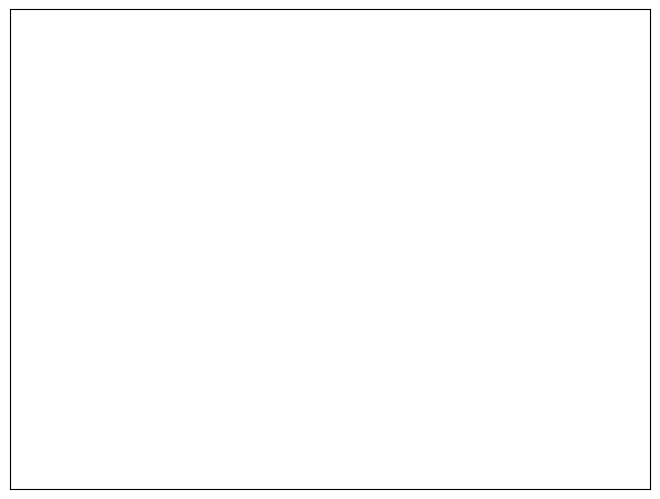

In [32]:
nx.draw(model,with_labels=True,arrowsize=30,node_size=800,alpha=0.3,font_weight='bold')

StopIteration: 

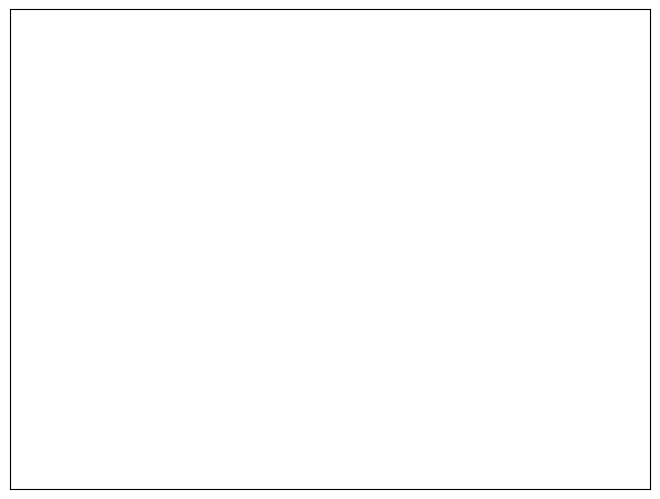

In [33]:
nx.draw(estimated_model,with_labels=True,arrowsize=30,node_size=800,alpha=0.3,font_weight='bold')